## Random Forest: Predicting Salary (USD)

This notebook trains a Random Forest regressor on the cleaned dataset `salaries_cleaned.csv`.
It includes preprocessing, training, evaluation, and saving the model.

In [1]:
!pip install scikit-learn

In [2]:
!pip install matplotlib seaborn 

In [3]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [4]:
# Load cleaned data
train_data = pd.read_csv('../train_df.csv')
test_data = pd.read_csv('../test_df.csv')

In [5]:
# Prepare target (log-transform) for both train and test datasets
train_data['salary_log'] = np.log1p(train_data['salary_in_usd'])
test_data['salary_log'] = np.log1p(test_data['salary_in_usd'])

print('Prepared salary_log target for both train and test; raw job_title kept as-is for fairness')
train_data[['job_title','salary_in_usd','salary_log']].head()

Prepared salary_log target for both train and test; raw job_title kept as-is for fairness


,job_title,salary_in_usd,salary_log
0,BI Developer,183300,12.118885
1,Applied Scientist,250000,12.429220
2,Product Manager,156160,11.958643
3,Engineer,255000,12.449023
4,Engineer,76000,11.238502


In [6]:
# Feature selection (use log-transformed target).

target = 'salary_log'

features = [
    'work_year',
    'experience_level',
    'employment_type',
    'job_title',
    'employee_residence',
    'remote_ratio',
    'company_location',
    'company_size'
]
# Build train / test feature matrices from provided datasets
X_train = train_data[features].copy()
y_train = train_data[target].copy()
X_test = test_data[features].copy()
y_test = test_data[target].copy()
print('Features used:', features)
print('X_train shape:', X_train.shape, 'y_train shape:', y_train.shape)
print('X_test shape:', X_test.shape, 'y_test shape:', y_test.shape)

Features used: ['work_year', 'experience_level', 'employment_type', 'job_title', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']
X_train shape: (41929, 8) y_train shape: (41929,)
X_test shape: (10483, 8) y_test shape: (10483,)


In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# Preprocessing: One-hot encode categorical features, scale numeric features
categorical_features = [
    'experience_level', 'employment_type', 'job_title',
    'employee_residence', 'company_location', 'company_size'
]
numeric_features = ['work_year', 'remote_ratio']

cat_pipe = Pipeline([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

num_pipe = Pipeline([
    ('scale', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', cat_pipe, categorical_features),
        ('num', num_pipe, numeric_features)
    ],
    remainder='drop'
)


In [8]:
# Build pipeline with Random Forest Regressor (we will tune hyperparameters)
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', rf)
])

# Hyperparameter tuning using RandomizedSearchCV (tune a few important params)
from sklearn.model_selection import RandomizedSearchCV
import time
param_dist = {
    'regressor__n_estimators': [100, 200, 400],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__max_features': ['sqrt', 'log2']
}
rand_search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=20,
                                 scoring='neg_mean_squared_error', cv=3, verbose=2, n_jobs=-1, random_state=42)
start = time.time()
rand_search.fit(X_train, y_train)
end = time.time()
print(f'RandomizedSearchCV done in {end-start:.1f}s')
print('Best params:', rand_search.best_params_)
# use best estimator as our final pipeline
pipeline = rand_search.best_estimator_
print('Best pipeline ready.')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   7.8s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   8.5s
[CV] END regressor__max_depth=10, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=   8.3s
[CV] END regressor__max_depth=None, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=  22.9s
[CV] END regressor__max_depth=None, regressor__max_features=sqrt, regressor__min_samples_split=2, regressor__n_estimators=100; total time=  22.5s
[CV] END regressor__max_depth=None, regressor__max_features=sqrt, regressor__min_samples_split=5, regressor__n_estimators=200; total time=  41.3s
[CV] END regressor__max_depth=None, regressor__max_features=sqrt, reg

In [9]:
# Predictions and evaluation
# pipeline predicts the log-target (salary_log). Invert with expm1 to get original USD scale
y_pred_log = pipeline.predict(X_test)
# invert log transform for both predictions and true values
y_pred_orig = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test)

mae = mean_absolute_error(y_test_orig, y_pred_orig)
mse = mean_squared_error(y_test_orig, y_pred_orig)
rmse = mse ** 0.5
r2 = r2_score(y_test_orig, y_pred_orig)

print(f'MAE: {mae:,.2f}')
print(f'RMSE: {rmse:,.2f}')
print(f'R^2: {r2:.4f}')

# Show a small comparison table (original scale)
comp = pd.DataFrame({
    'actual_usd': y_test_orig,
    'predicted_usd': y_pred_orig
})
comp.reset_index(drop=True, inplace=True)
comp.head(10)


MAE: 46,517.06
RMSE: 66,717.09
R^2: 0.2723


,actual_usd,predicted_usd
0,89000.0,128900.410630
1,123365.0,128900.410630
2,46160.0,93227.056997
3,167981.0,147619.143817
4,67725.0,93113.496534
5,231100.0,195252.925555
6,175600.0,160764.826695
7,97300.0,125756.631125
8,98300.0,174494.611698
9,61781.0,55006.569013


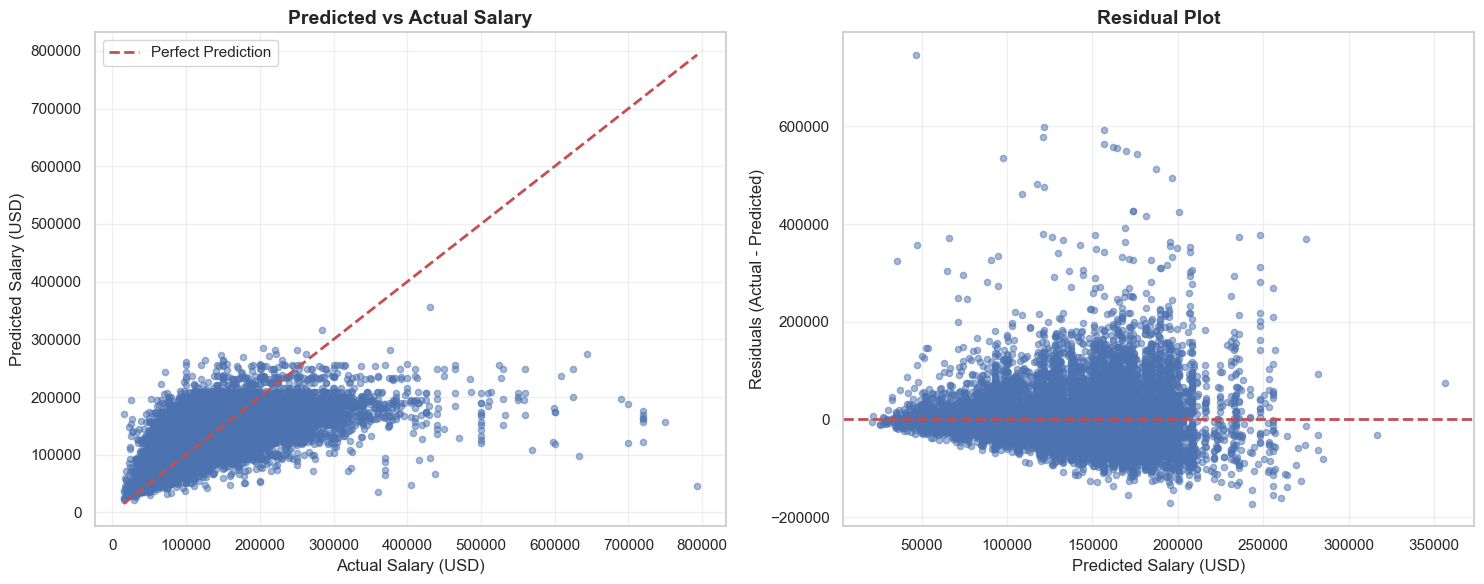


Prediction Statistics:
Mean Absolute Error: $46,517.06
Root Mean Squared Error: $66,717.09
R² Score: 0.2723

Mean Actual Salary: $151,844.92
Mean Predicted Salary: $141,546.76
Mean Residual: $10,298.16


In [10]:
# Visualization: Predicted vs Actual Values
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot: Predicted vs Actual
axes[0].scatter(y_test_orig, y_pred_orig, alpha=0.5, s=20)
axes[0].plot([y_test_orig.min(), y_test_orig.max()], 
             [y_test_orig.min(), y_test_orig.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Salary (USD)', fontsize=12)
axes[0].set_ylabel('Predicted Salary (USD)', fontsize=12)
axes[0].set_title('Predicted vs Actual Salary', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals = y_test_orig - y_pred_orig
axes[1].scatter(y_pred_orig, residuals, alpha=0.5, s=20)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Salary (USD)', fontsize=12)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print some statistics
print(f'\nPrediction Statistics:')
print(f'Mean Absolute Error: ${mae:,.2f}')
print(f'Root Mean Squared Error: ${rmse:,.2f}')
print(f'R² Score: {r2:.4f}')
print(f'\nMean Actual Salary: ${y_test_orig.mean():,.2f}')
print(f'Mean Predicted Salary: ${y_pred_orig.mean():,.2f}')
print(f'Mean Residual: ${residuals.mean():,.2f}')

In [11]:
# Feature importances (map back to column names)
pre = pipeline.named_steps['preprocessor']
# get feature names from the ColumnTransformer and OneHotEncoder
try:
    ohe = pre.named_transformers_['cat'].named_steps['ohe']
    cat_names = ohe.get_feature_names_out(categorical_features)
    num_names = numeric_features
    feature_names = list(cat_names) + list(num_names)
except Exception:
    feature_names = None

# extract importances from the fitted RandomForestRegressor
rf_model = pipeline.named_steps['regressor']
importances = rf_model.feature_importances_

if feature_names is not None and len(feature_names) == len(importances):
    feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})
else:
    feat_imp = pd.DataFrame({'feature': [f'f{i}' for i in range(len(importances))], 'importance': importances})

feat_imp = feat_imp.sort_values('importance', ascending=False).reset_index(drop=True)
feat_imp.head(30)

,feature,importance
0,experience_level_EN,0.083571
1,experience_level_SE,0.078352
2,employee_residence_US,0.071098
3,company_location_US,0.065350
4,job_title_Data Analyst,0.050108
5,work_year,0.040683
6,experience_level_MI,0.032579
7,job_title_Machine Learning Engineer,0.022983
8,experience_level_EX,0.022053
9,remote_ratio,0.020165


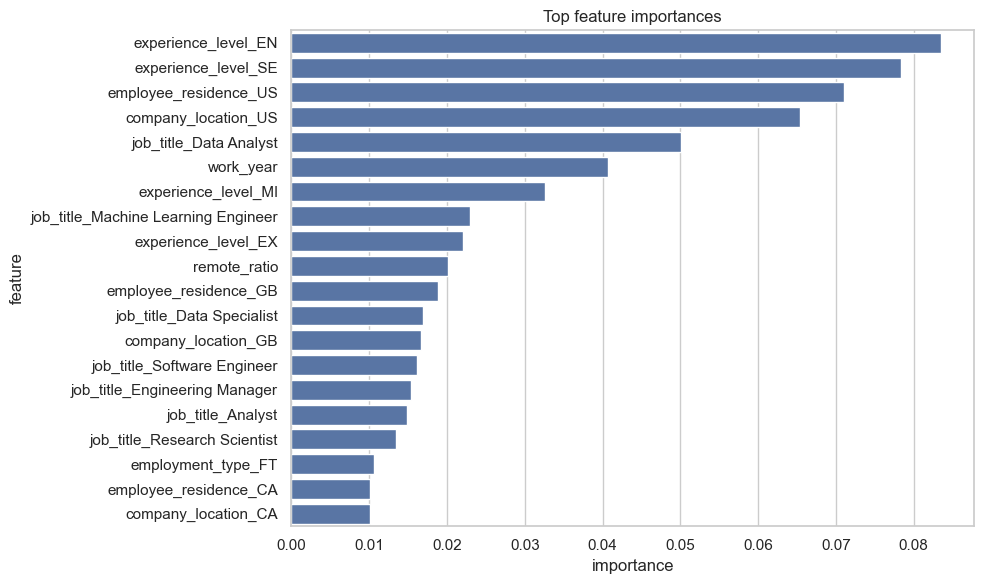

In [12]:
# Plot top 20 feature importances
top_n = 20
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_imp.head(top_n))
plt.title('Top feature importances')
plt.tight_layout()
plt.show()

In [13]:
# Save trained pipeline to disk
model_path = 'rf_salary_pipeline.joblib'
joblib.dump(pipeline, model_path)
print(f'Model pipeline saved to: {model_path}')

Model pipeline saved to: rf_salary_pipeline.joblib
